<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [2]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [3]:
 URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [4]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [5]:
import pandas as pd
# Path to the CSV file. The first row is treated as headers by default (header=0).
data_path = "dataset.csv"
# Read the CSV file into a DataFrame. Assumes the first row contains headers.
df = pd.read_csv(data_path)
# Generate descriptive statistics for all columns, including object (categorical) types.
description = df.describe(include="all")
# Output the description to stdout
print(description)

          model          year transmission        mileage fuelType  \
count     17966  17966.000000        17966   17966.000000    17966   
unique       24           NaN            3            NaN        5   
top      Fiesta           NaN       Manual            NaN   Petrol   
freq       6557           NaN        15518            NaN    12179   
mean        NaN   2016.866470          NaN   23362.608761      NaN   
std         NaN      2.050336          NaN   19472.054349      NaN   
min         NaN   1996.000000          NaN       1.000000      NaN   
25%         NaN   2016.000000          NaN    9987.000000      NaN   
50%         NaN   2017.000000          NaN   18242.500000      NaN   
75%         NaN   2018.000000          NaN   31060.000000      NaN   
max         NaN   2060.000000          NaN  177644.000000      NaN   

                 tax           mpg    engineSize         price  
count   17963.000000  17966.000000  17966.000000  17966.000000  
unique           NaN         

In [6]:
print(df.columns)

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'price'],
      dtype='object')


In [7]:
df.head(5)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


In [8]:
# Identify columns with any missing values
missing_columns = df.columns[df.isna().any()].tolist()
print(missing_columns)

['tax']


In [9]:
# Identify numeric columns to fill with their column means
numeric_columns = df.select_dtypes(include=['number']).columns
print(numeric_columns)

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price'], dtype='object')


In [10]:
# Compute means for numeric columns
means = df[numeric_columns].mean()
print(means)

year           2016.866470
mileage       23362.608761
tax             113.329177
mpg              57.906980
engineSize        1.350807
price         12279.534844
dtype: float64


In [11]:
# Replace missing values in numeric columns with their respective means
for col in numeric_columns:
    df[col] = df[col].fillna(means[col])

In [12]:
# Remove duplicate rows from the dataframe
df = df.drop_duplicates()
print(df)

         model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0       Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1        Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2        Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3       Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4       Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   
...        ...   ...          ...      ...      ...    ...   ...         ...   
17961    B-MAX  2017       Manual    16700   Petrol  150.0  47.1         1.4   
17962    B-MAX  2014       Manual    40700   Petrol   30.0  57.7         1.0   
17963    Focus  2015       Manual     7010   Diesel   20.0  67.3         1.6   
17964       KA  2018       Manual     5007   Petrol  145.0  57.7         1.2   
17965    Focus  2015       Manual     5007   Petrol   22.0  57.7         1.0   

       price  
0      12000  
1      14

In [21]:
# Assuming your cleaned DataFrame is named 'df_cleaned'
df.to_csv('cleaned_dataset.csv', index=False)

In [13]:
import pandas as pd
numeric_df = df.select_dtypes(include=['number'])
# Assume df is your DataFrame and replace 'target' with the actual target column name
target_col = 'price'

# Compute Pearson correlations with the target, take absolute values,
# exclude the target column, then take the top 5 feature names
top_features = (
    numeric_df.corr()[target_col]
    .abs()
    .drop(labels=[target_col])
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

print("Top 5 attributes most correlated with", target_col, ":", top_features)

Top 5 attributes most correlated with price : ['year', 'mileage', 'engineSize', 'tax', 'mpg']


In [14]:
column_name = 'fuelType'  # replace with your column name
counts = df[column_name].value_counts()
print(counts)

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


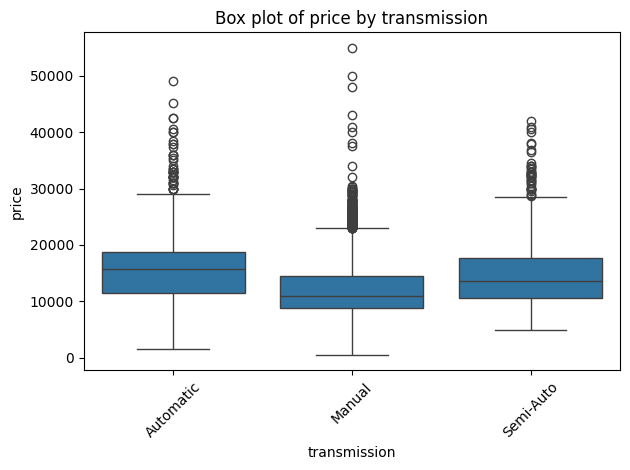

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your pandas DataFrame with columns specified by source_attr and target_attr
source_attr = 'transmission'  # replace with your categorical/source column name
target_attr = 'price'  # replace with your numeric/target column name

# Create a box plot showing distribution of target_attr for each category in source_attr
sns.boxplot(x=source_attr, y=target_attr, data=df)
plt.xlabel(source_attr)
plt.ylabel(target_attr)
plt.title(f'Box plot of {target_attr} by {source_attr}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

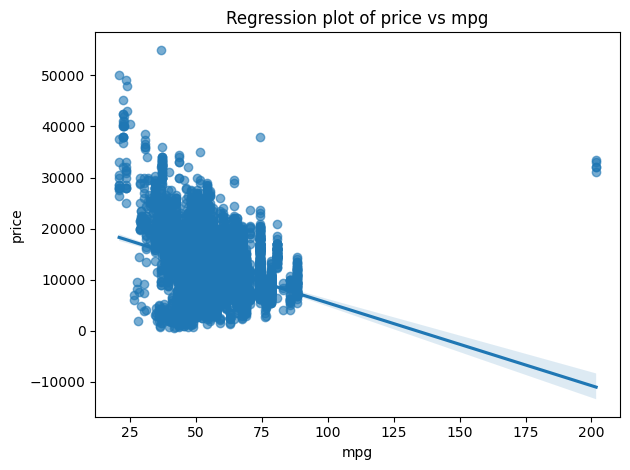

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your pandas DataFrame with numeric 'source' and 'target' columns
source_attr = 'mpg'  # replace with your source column name
target_attr = 'price'  # replace with your target column name

# Regression plot showing relationship between source_attr ( Predictor ) and target_attr ( Response )
sns.regplot(x=source_attr, y=target_attr, data=df, scatter_kws={'alpha': 0.6})
plt.xlabel(source_attr)
plt.ylabel(target_attr)
plt.title(f'Regression plot of {target_attr} vs {source_attr}')
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

# Assume df is a pandas DataFrame with numeric 'source' (predictor) and 'target' (response) columns
X = df['price'].values.reshape(-1, 1)
y = df['mpg'].values.reshape(-1, 1)
n = X.shape[0]

# Add bias term to incorporate the intercept: X_b = [1, X]
X_b = np.hstack([np.ones((n, 1)), X])

# Closed-form solution for linear regression: theta = (X_b^T X_b)^{-1} X_b^T y
beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

y_pred = X_b.dot(beta)

# Extract coefficients (optional)
intercept = float(beta[0, 0])
slope = float(beta[1, 0])

# Compute R^2 and Mean Squared Error (MSE)
ss_res = float(((y - y_pred) ** 2).sum())
ss_tot = float(((y - y.mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot
mse = ss_res / n

print("Intercept:", intercept)
print("Slope:", slope)
print("R^2:", r2)
print("MSE:", mse)

Intercept: 66.99782024871844
Slope: -0.0007407866783731298
R^2: 0.11989802249624171
MSE: 90.35634461427878


In [ ]:
numeric_features = df.select_dtypes(include=['number']).columns.drop('price')


In [19]:
import numpy as np
import pandas as pd

# DataFrame df with numeric features and a target column named 'target'
target_col = 'price'
feature_cols = df.select_dtypes(include=['number']).columns.drop(target_col)

X = df[feature_cols].values  # shape (n_samples, n_features)
y = df[target_col].values.reshape(-1, 1)  # shape (n_samples, 1)

valid_idx = ~np.isnan(X).any(axis=1) & ~np.isnan(y).flatten()
X = X[valid_idx]
y = y[valid_idx]

# Add bias term
ones = np.ones((X.shape[0], 1))
X_b = np.hstack([ones, X])  # (n_samples, n_features+1)

# Normal equation with pseudo-inverse for numerical stability
theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)  # (n_features+1, 1)

# Predictions
y_pred = X_b.dot(theta)  # (n_samples, 1)

# R^2 and MSE
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot
n = y.shape[0]
mse = ss_res / n

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.5987150421664551
MSE: 9001279.131880678


In [20]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Assumes an existing DataFrame named df
# 1) Define target and select numeric source features (excluding the target)
target_col = 'price'  # replace with your actual target column name
source_cols = df.select_dtypes(include=[np.number]).columns.tolist()
source_cols = [c for c in source_cols if c != target_col]

X = df[source_cols].values
y = df[target_col].values

# 2) Create and fit the pipeline: StandardScaler -> PolynomialFeatures(degree=2) -> LinearRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
pipeline.fit(X, y)

# 3) Evaluate R^2 and MSE on training data
y_pred = pipeline.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print('R^2:', r2)
print('MSE:', mse)

R^2: 0.7666619695239302
MSE: 5234038.065462741


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Assuming an existing DataFrame named df
# 1) Define target and feature columns
target_col = 'price'  # replace with your actual target column name
feature_cols = df.select_dtypes(include=['number']).columns.drop(target_col)

X = df[feature_cols].values
y = df[target_col].values

# 2) Split data into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Create and fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# 4) Predict on test data
y_pred = ridge_model.predict(X_test)

# 5) Compute MSE and R^2 on test data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.6917134446113066
MSE: 6912725.801055086


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Assuming an existing DataFrame named df
# 1) Define target and feature columns
target_col = 'price'
feature_cols = df.select_dtypes(include=['number']).columns.drop(target_col)

X = df[feature_cols].values
y = df[target_col].values

# 2) Split data into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Apply second-degree polynomial features to the data
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 4) Create and fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_poly, y_train)

# 5) Predict on test data and evaluate
y_pred = ridge_model.predict(X_test_poly)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('R^2:', r2)
print('MSE:', mse)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


R^2: 0.673274888823681
MSE: 7326174.5165419085


In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Assuming an existing DataFrame named df
# 1) Define target and feature columns
target_col = 'price'  # replace with your actual target column name
feature_cols = df.select_dtypes(include=['number']).columns.drop(target_col)
X = df[feature_cols].values
y = df[target_col].values

# 2) Split data into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Create a pipeline: PolynomialFeatures (degree 2) + Ridge regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

# 4) Grid search over Ridge alpha values with cross-validation
param_grid = {'ridge__alpha': [0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(estimator=pipeline,
                    param_grid=param_grid,
                    cv=5,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1)
grid.fit(X_train, y_train)

# Best estimator from grid search
best_model = grid.best_estimator_

# 5) Predict on test data and evaluate
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Best alpha:', grid.best_params_.get('ridge__alpha'))
print('R^2:', r2)
print('MSE:', mse)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.70402e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.76139e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.75044e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.74159e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.64731e-24): res

Best alpha: 0.1
R^2: 0.673274888823681
MSE: 7326174.5165419085


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
